# Exploratory Data Analysis of San Diego Energy Load

This notebook performs a detailed Exploratory Data Analysis (EDA) on the synthetically generated energy load data. The goal is to understand the data's structure, verify its characteristics against the generator's logic, and uncover key patterns that will inform the forecasting models.

## 1. Setup and Imports

In [4]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Configuration for plots ---
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14

## 2. Load and Inspect Data

In [5]:
try:
    df = pd.read_csv("data/san_diego_energy_load_data.csv")
    print("Dataset loaded successfully.")
    print(f"Shape of the dataset: {df.shape}")
except FileNotFoundError:
    print("Error: 'san_diego_energy_load_data.csv' not found.")
    print("Please run the data generator script first.")

Dataset loaded successfully.
Shape of the dataset: (9737208, 16)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9737208 entries, 0 to 9737207
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Id                int64  
 1   TradeDate         object 
 2   TradeTime         object 
 3   LoadProfile       object 
 4   RateGroup         object 
 5   BaseLoad          float64
 6   LossAdjustedLoad  float64
 7   MeterCount        int64  
 8   LoadBL            float64
 9   LoadLAL           float64
 10  LoadMeterCount    int64  
 11  GenBL             float64
 12  GenLAL            float64
 13  GenMeterCount     int64  
 14  Submission        object 
 15  Created           object 
dtypes: float64(6), int64(4), object(6)
memory usage: 1.2+ GB


In [7]:
df.head()

,Id,TradeDate,TradeTime,LoadProfile,RateGroup,BaseLoad,LossAdjustedLoad,MeterCount,LoadBL,LoadLAL,LoadMeterCount,GenBL,GenLAL,GenMeterCount,Submission,Created
0,1,2020-01-01,00:00,Residential,RES-TOU-A,3232.47,3426.42,2552,3232.47,3426.42,2552,0.0,0.0,0,Final,2020-01-01 01:00:00
1,2,2020-01-01,00:00,Residential,RES-TOU-B,1622.12,1719.44,2408,1622.12,1719.44,2408,0.0,0.0,0,Final,2020-01-01 01:00:00
2,3,2020-01-01,00:00,Residential,RES-TOU-C,1164.33,1234.20,2409,1164.33,1234.20,2409,0.0,0.0,0,Final,2020-01-01 01:00:00
3,4,2020-01-01,00:00,Residential,RES-TIER-1,1884.80,1997.90,2425,1884.80,1997.90,2425,0.0,0.0,0,Final,2020-01-01 01:00:00
4,5,2020-01-01,00:00,Residential,RES-TIER-2,1983.66,2102.67,2593,1983.66,2102.67,2593,0.0,0.0,0,Final,2020-01-01 01:00:00


In [8]:
df.describe()

,Id,BaseLoad,LossAdjustedLoad,MeterCount,LoadBL,LoadLAL,LoadMeterCount,GenBL,GenLAL,GenMeterCount
count,9.737208e+06,9.737208e+06,9.737208e+06,9.737208e+06,9.737208e+06,9.737208e+06,9.737208e+06,9.737208e+06,9.737208e+06,9.737208e+06
mean,4.868604e+06,1.810105e+03,1.895857e+03,2.033627e+03,2.674547e+03,2.807972e+03,1.602811e+03,-8.644420e+02,-9.121149e+02,4.308157e+02
std,2.810890e+06,2.080131e+03,2.190519e+03,1.640134e+03,1.495912e+03,1.573238e+03,1.257133e+03,1.749359e+03,1.852404e+03,5.101988e+02
min,1.000000e+00,-1.841169e+04,-1.951639e+04,1.900000e+01,-2.231550e+03,-2.298500e+03,1.800000e+01,-2.191296e+04,-2.322774e+04,0.000000e+00
25%,2.434303e+06,9.727400e+02,1.017980e+03,3.600000e+01,1.605200e+03,1.683500e+03,2.700000e+01,-9.488800e+02,-9.871900e+02,0.000000e+00
50%,4.868604e+06,1.878130e+03,1.968830e+03,2.623000e+03,2.404700e+03,2.523880e+03,2.468000e+03,0.000000e+00,0.000000e+00,1.000000e+01
75%,7.302906e+06,2.922610e+03,3.065240e+03,3.593000e+03,3.459020e+03,3.632720e+03,2.647000e+03,0.000000e+00,0.000000e+00,1.026000e+03
max,9.737208e+06,1.704842e+04,1.807132e+04,4.743000e+03,1.972891e+04,2.091265e+04,3.414000e+03,1.309310e+03,1.387880e+03,1.355000e+03


## 3. Data Preprocessing & Feature Engineering

In [9]:
# Combine Date and Time into a single datetime object
df["Timestamp"] = pd.to_datetime(df["TradeDate"] + " " + df["TradeTime"])

# Set the new Timestamp as the index for time-series analysis
df.set_index("Timestamp", inplace=True)

# CRITICAL STEP: Sort the DataFrame by the new DatetimeIndex to ensure it is monotonic
# This prevents errors during time-based slicing.
df.sort_index(inplace=True)

# Create derived features for easier analysis
df["Year"] = df.index.year
df["Month"] = df.index.month
df["DayOfWeek"] = df.index.day_name()
df["Hour"] = df.index.hour

# Create a 'Solar_Status' column based on the 'NEM' keyword in RateGroup [cite: 48, 142]
df["Solar_Status"] = df["RateGroup"].apply(
    lambda x: "Solar" if "NEM" in x else "Non-Solar"
)

print("Preprocessing complete. 'Timestamp' index and time features created.")

Preprocessing complete. 'Timestamp' index and time features created.


## 4. Data Consistency Checks

In [10]:
# Check if BaseLoad ≈ LoadBL + GenBL [cite: 57]
df["Load_Check"] = df["LoadBL"] + df["GenBL"]
consistency_diff = (df["BaseLoad"] - df["Load_Check"]).abs().mean()

print(
    f"Mean absolute difference between BaseLoad and (LoadBL + GenBL): {consistency_diff:.4f}"
)
if consistency_diff < 0.01:
    print("✅ Consistency Check Passed: BaseLoad is consistent with its components.")
else:
    print("⚠️ Consistency Check Failed: Investigate BaseLoad calculation.")

Mean absolute difference between BaseLoad and (LoadBL + GenBL): 0.0015
✅ Consistency Check Passed: BaseLoad is consistent with its components.


## 5. Univariate Analysis

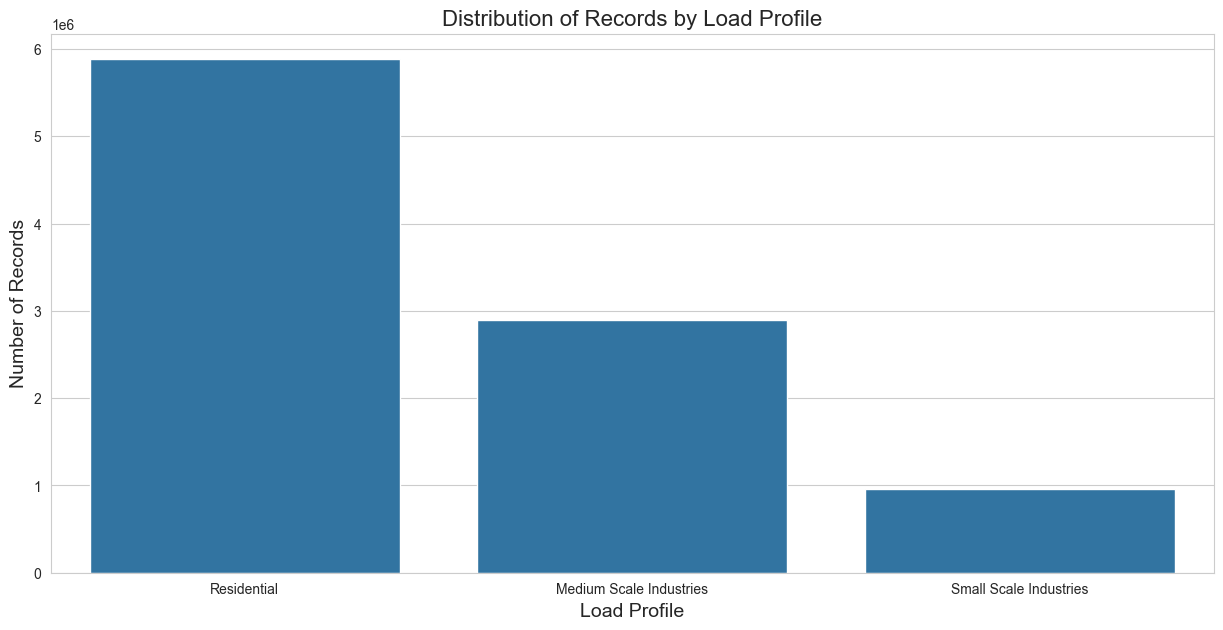

In [11]:
# Plot distribution of LoadProfile
plt.figure()
sns.countplot(data=df, x="LoadProfile", order=df["LoadProfile"].value_counts().index)
plt.title("Distribution of Records by Load Profile")
plt.ylabel("Number of Records")
plt.xlabel("Load Profile")
plt.show()

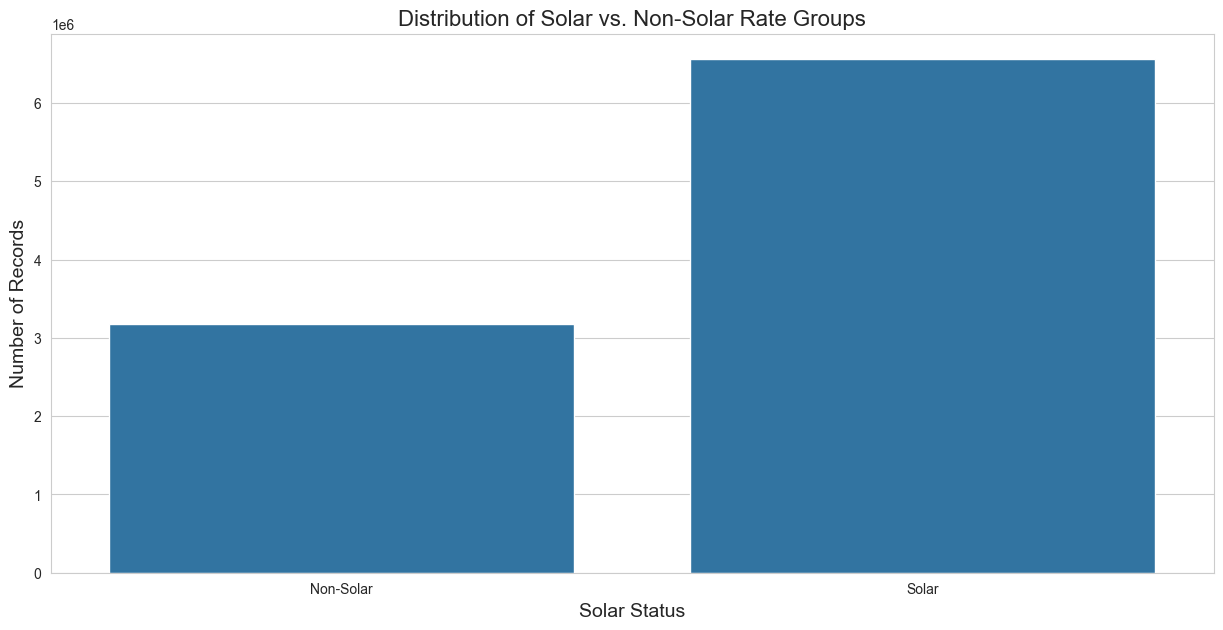

In [12]:
# Plot distribution of Solar vs Non-Solar
plt.figure()
sns.countplot(data=df, x="Solar_Status")
plt.title("Distribution of Solar vs. Non-Solar Rate Groups")
plt.ylabel("Number of Records")
plt.xlabel("Solar Status")
plt.show()

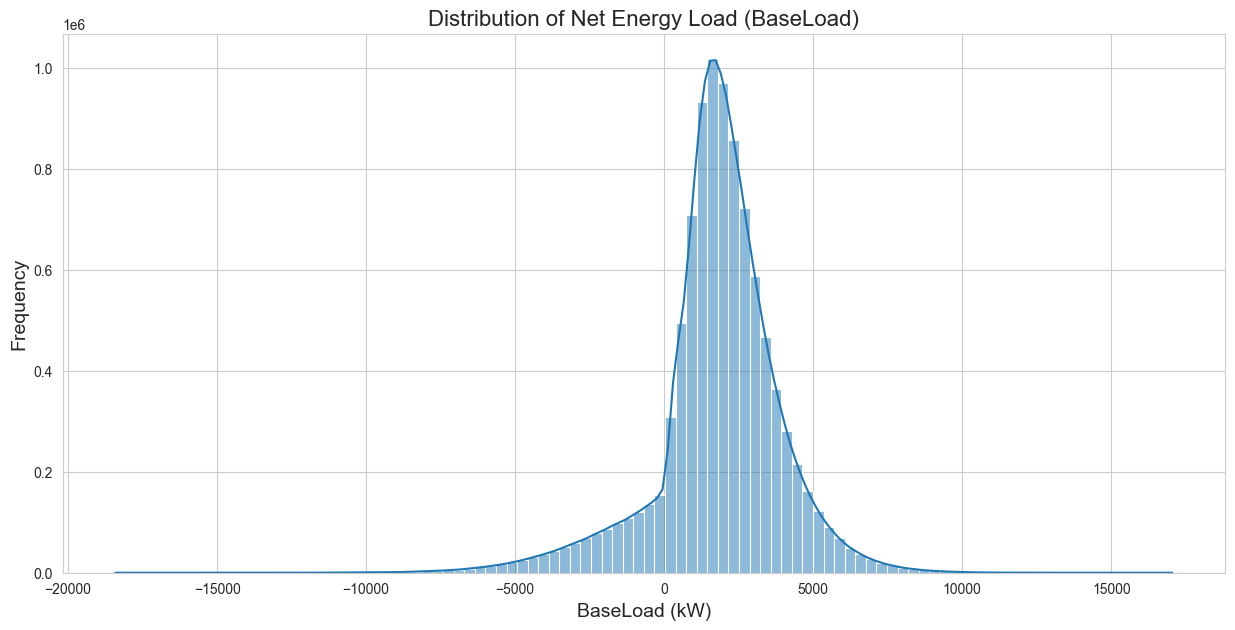

In [13]:
# Plot distribution of BaseLoad
plt.figure()
sns.histplot(df["BaseLoad"], bins=100, kde=True)
plt.title("Distribution of Net Energy Load (BaseLoad)")
plt.xlabel("BaseLoad (kW)")
plt.ylabel("Frequency")
plt.show()

The `BaseLoad` distribution is multi-modal, with a large peak for positive consumption and a smaller tail for negative values, representing periods of net solar generation[cite: 56].

## 6. Bivariate & Multivariate Analysis

### Temporal Pattern Analysis

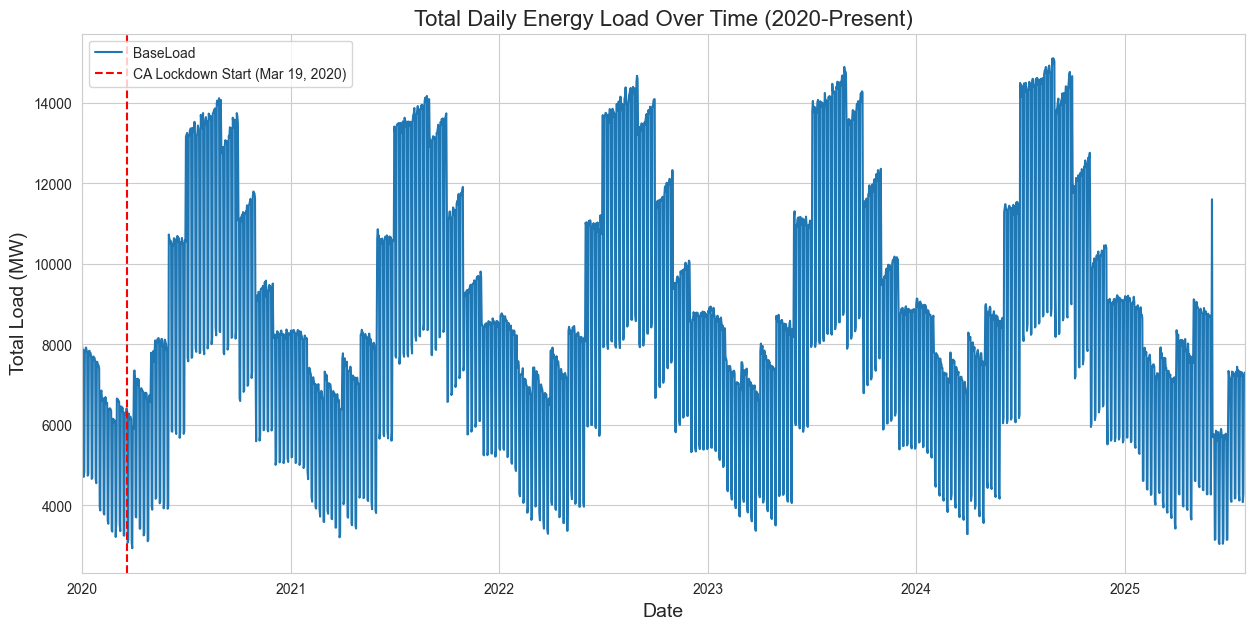

In [14]:
# Plot overall daily aggregated load
daily_load = df.resample("D")["BaseLoad"].sum() / 1000  # In MegaWatts
plt.figure()
daily_load.plot()
plt.title("Total Daily Energy Load Over Time (2020-Present)")
plt.ylabel("Total Load (MW)")
plt.xlabel("Date")
# Mark COVID-19 lockdown start for context [cite: 347]
plt.axvline(
    datetime(2020, 3, 19),
    color="red",
    linestyle="--",
    label="CA Lockdown Start (Mar 19, 2020)",
)
plt.legend()
plt.show()

The plot above clearly shows seasonal peaks and a significant structural break around the start of the COVID-19 pandemic in March 2020, which aligns with the data generator's design[cite: 301].

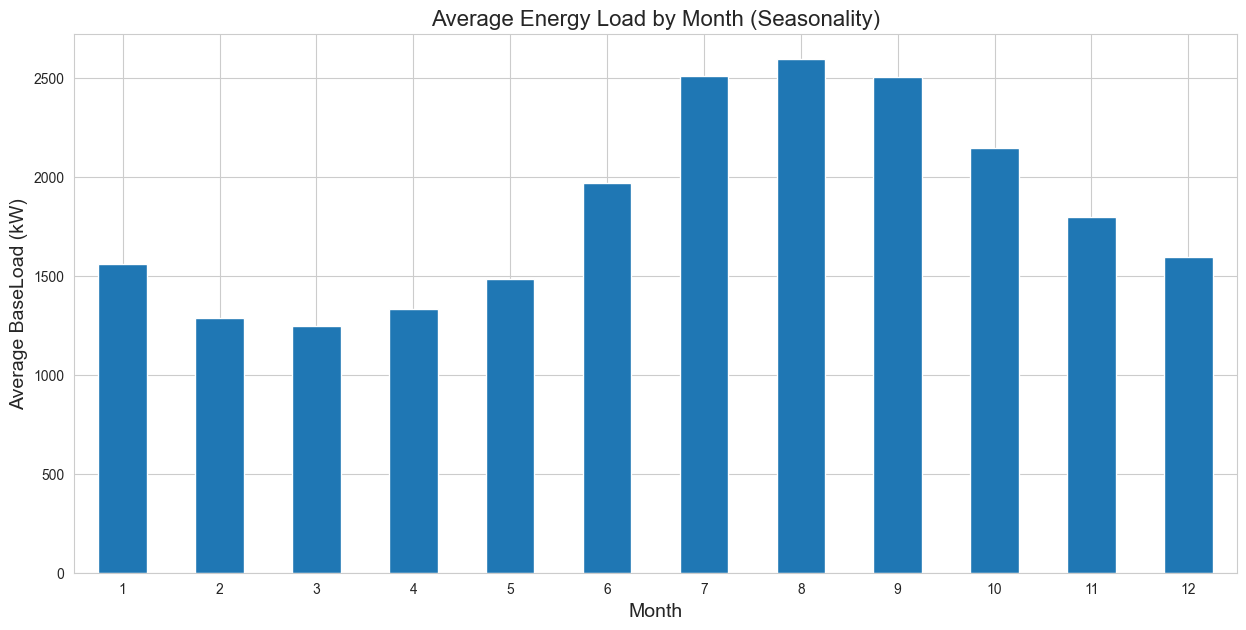

In [15]:
# Plot average load by month (Seasonality)
monthly_load = df.groupby("Month")["BaseLoad"].mean()
plt.figure()
monthly_load.plot(kind="bar")
plt.title("Average Energy Load by Month (Seasonality)")
plt.ylabel("Average BaseLoad (kW)")
plt.xlabel("Month")
plt.xticks(rotation=0)
plt.show()

As expected from the San Diego climate modeling, summer months (June-September) exhibit higher average consumption[cite: 292].

### Diurnal (Hourly) Pattern Analysis

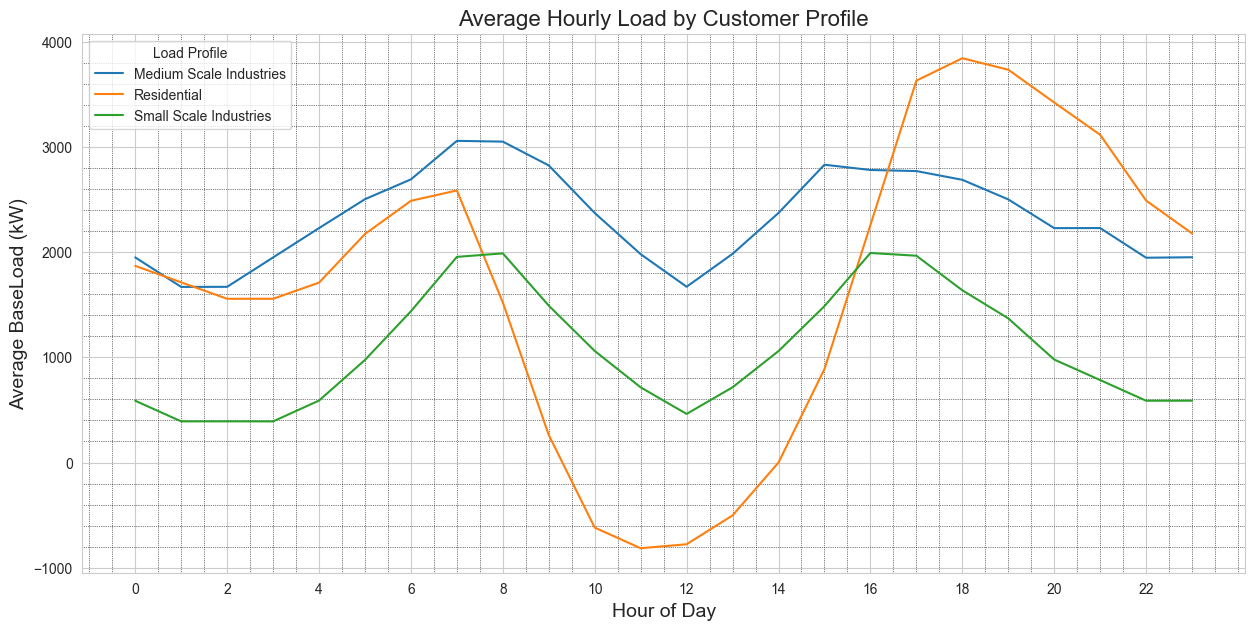

In [16]:
# Plot average hourly load by Load Profile
plt.figure()
df.groupby(["LoadProfile", "Hour"])["BaseLoad"].mean().unstack(level=0).plot(
    ax=plt.gca()
)
plt.title("Average Hourly Load by Customer Profile")
plt.ylabel("Average BaseLoad (kW)")
plt.xlabel("Hour of Day")
plt.xticks(np.arange(0, 24, 2))
plt.grid(which="minor", linestyle=":", linewidth="0.5", color="black")
plt.minorticks_on()
plt.legend(title="Load Profile")
plt.show()

The diurnal patterns match the requirements document's expectations[cite: 136, 137, 138]:
* **Residential**: Bimodal peaks in the morning and evening.
* **Small/Medium Industries**: A single, broad peak during business hours.

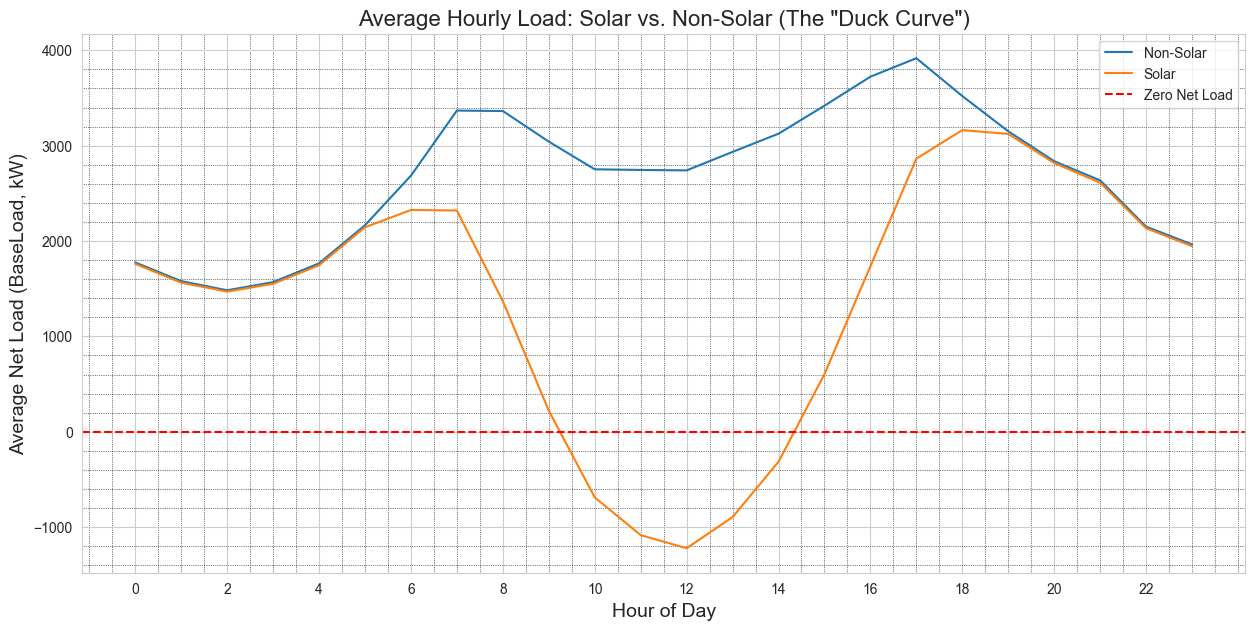

In [17]:
# Plot the "Duck Curve": Solar vs. Non-Solar hourly patterns
plt.figure()
df.groupby(["Solar_Status", "Hour"])["BaseLoad"].mean().unstack(level=0).plot(
    ax=plt.gca()
)
plt.title('Average Hourly Load: Solar vs. Non-Solar (The "Duck Curve")')
plt.ylabel("Average Net Load (BaseLoad, kW)")
plt.xlabel("Hour of Day")
plt.axhline(0, color="red", linestyle="--", label="Zero Net Load")
plt.xticks(np.arange(0, 24, 2))
plt.grid(which="minor", linestyle=":", linewidth="0.5", color="black")
plt.minorticks_on()
plt.legend()
plt.show()

This plot clearly shows the famous "duck curve." For solar-enabled rate groups, the net load dips significantly during midday due to solar generation, aligning with the model's solar intelligence feature[cite: 295, 296].

### In-depth COVID-19 Impact Analysis

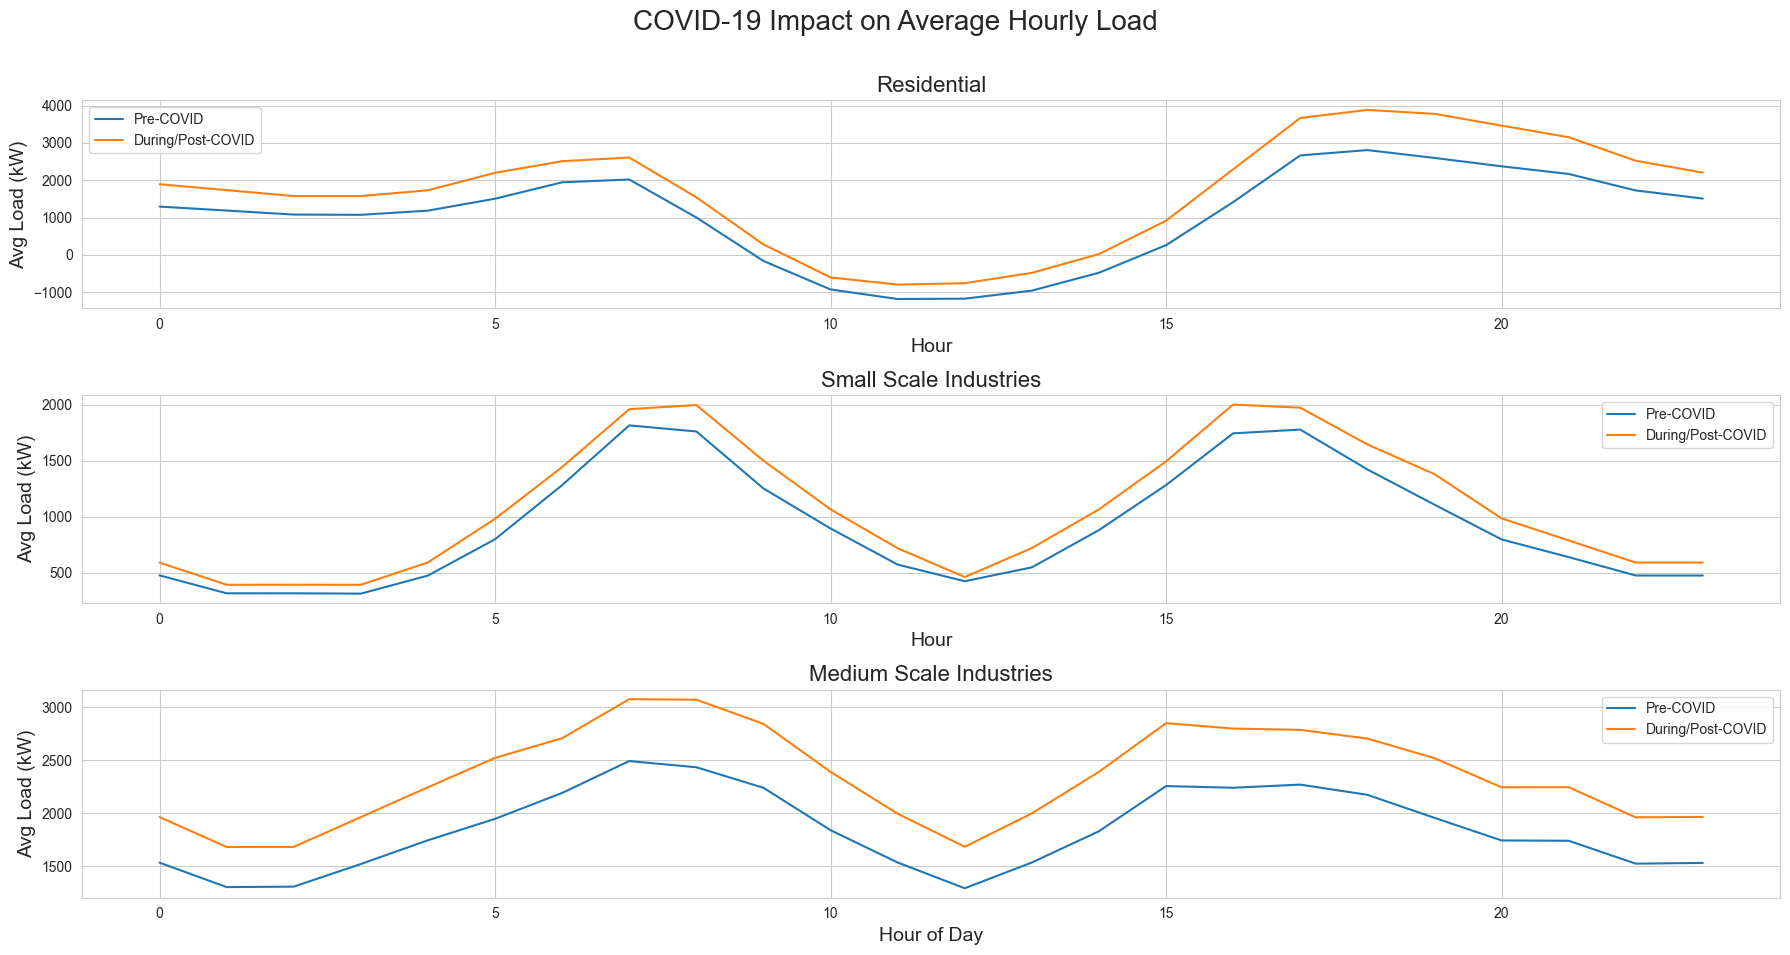

In [18]:
# Compare pre-COVID vs. during-COVID load for each profile
covid_start_date = "2020-03-19"
pre_covid_df = df.loc[:covid_start_date]
covid_df = df.loc[covid_start_date:]

plt.figure(figsize=(18, 10))
plt.suptitle("COVID-19 Impact on Average Hourly Load", fontsize=20)

# Residential [cite: 348]
ax1 = plt.subplot(3, 1, 1)
pre_covid_df[pre_covid_df["LoadProfile"] == "Residential"].groupby("Hour")[
    "BaseLoad"
].mean().plot(ax=ax1, label="Pre-COVID")
covid_df[covid_df["LoadProfile"] == "Residential"].groupby("Hour")[
    "BaseLoad"
].mean().plot(ax=ax1, label="During/Post-COVID")
plt.title("Residential")
plt.ylabel("Avg Load (kW)")
plt.legend()

# Small Scale Industries [cite: 349]
ax2 = plt.subplot(3, 1, 2)
pre_covid_df[pre_covid_df["LoadProfile"] == "Small Scale Industries"].groupby("Hour")[
    "BaseLoad"
].mean().plot(ax=ax2, label="Pre-COVID")
covid_df[covid_df["LoadProfile"] == "Small Scale Industries"].groupby("Hour")[
    "BaseLoad"
].mean().plot(ax=ax2, label="During/Post-COVID")
plt.title("Small Scale Industries")
plt.ylabel("Avg Load (kW)")
plt.legend()

# Medium Scale Industries [cite: 350]
ax3 = plt.subplot(3, 1, 3)
pre_covid_df[pre_covid_df["LoadProfile"] == "Medium Scale Industries"].groupby("Hour")[
    "BaseLoad"
].mean().plot(ax=ax3, label="Pre-COVID")
covid_df[covid_df["LoadProfile"] == "Medium Scale Industries"].groupby("Hour")[
    "BaseLoad"
].mean().plot(ax=ax3, label="During/Post-COVID")
plt.title("Medium Scale Industries")
plt.ylabel("Avg Load (kW)")
plt.xlabel("Hour of Day")
plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

The analysis validates the generator's COVID-19 modeling:
* Residential daytime load increased due to work-from-home policies[cite: 302].
* Industrial and commercial load decreased significantly, especially during business hours[cite: 303].

---

## 7. Conclusion
The EDA confirms that the generated dataset is rich, complex, and aligns well with the specifications outlined in the requirements and generator documents. The data exhibits clear temporal patterns, customer segmentation differences, and the significant structural impact of the COVID-19 pandemic. These insights provide a solid foundation for the feature engineering and modeling phases of the project.